
#### 1. Тестовые данные
Подготовить следующий тестовый набор:

- enwik7 (первые 1E+7 байт enwik9 [https://mattmahoney.net/dc/textdata.html])
- текст на русском языке, объемом не менее 200Кб
- бинарный файл объемом не менее 1 Мб, содержимое которого не представляет собой осмысленный текст. Например, произвольный .exe файл
- Черно-белое изображение, размером не менее 800x600 пикселей
- Изображение в оттенках серого, размером не менее 800x600 пикселей
- Цветное изображение, размером не менее 800x600 пикселей

Перевести изображения в собственный raw формат, в котором один/три байта задают значение цветности пикселя. Дополнить файл метаданными о типе (чб/оттенки серого/цветное). Сравнить размер получившегося файла с размером изображения и сделать приблизительную оценку коэффициента сжатия исходного изображения в формате jpg, png и т.д.


In [1]:
import os
import struct
from PIL import Image
import matplotlib.pyplot as plt


class ImageProcessor:
    """Конвертация изображений в кастомный RAW формат."""

    @staticmethod
    def to_raw(image_path: str, output_path: str, **convert_kwargs):
        with Image.open(image_path) as old_img:
            img = old_img
            if convert_kwargs:
                img = old_img.convert(**convert_kwargs)

            mode = img.mode
            width, height = img.size
            mode_id = {'1': 0, 'L': 1, 'RGB': 2}.get(mode, 2)
            raw_data = img.tobytes()

            # [1 байт тип][4 байт ширина][4 байт высота][данные]
            # 0 - BW, 1 - Grayscale, 2 - RGB
            with open(output_path, 'wb') as f:
                f.write(struct.pack('>BII', mode_id, width, height))
                f.write(raw_data)

            original_size = os.path.getsize(image_path)
            raw_size = os.path.getsize(output_path)
            ratio = original_size / raw_size if raw_size > 0 else 0
            return mode_id, raw_size, ratio


def show_raw(raw_path):
    with open(raw_path, 'rb') as f:
        header = f.read(9)
        mode_id, width, height = struct.unpack('>BII', header)
        raw_data = f.read()

    # 0 -> '1' (BW), 1 -> 'L' (Grayscale), 2 -> 'RGB'
    mode = {0: '1', 1: 'L', 2: 'RGB'}.get(mode_id, 'RGB')
    img = Image.frombytes(mode, (width, height), raw_data)

    plt.imshow(img, cmap='gray' if mode == 'L' or mode == '1' else None)
    plt.title(f"Format: {img.mode}, Size: {width}x{height}")
    plt.axis('off')
    plt.show()


processor = ImageProcessor
BASE_IMAGE_PATH = "resources/images/"

In [2]:
def process_image(img_name: str, mode: str):
    _, raw_size, ratio = processor.to_raw(
        BASE_IMAGE_PATH + img_name,
        BASE_IMAGE_PATH + img_name + ".raw",
        mode=mode, dither=Image.Dither.NONE
    )

    print(f"{raw_size=}, {1/ratio=} (compressed)")
    show_raw(BASE_IMAGE_PATH + img_name + ".raw")

raw_size=109929, 1/ratio=2.5868690434168724 (compressed)


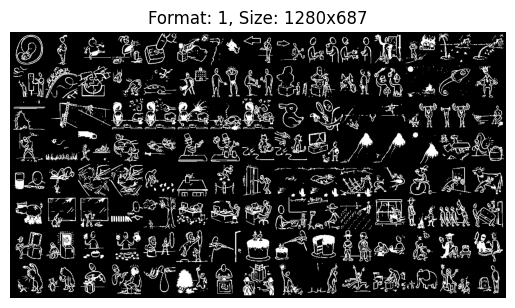

In [3]:
with Image.open(BASE_IMAGE_PATH + "original-moral.png") as img:
    img = img.convert(mode="1")
    img.save(BASE_IMAGE_PATH + "monochrome.png")


process_image("monochrome.png", "1")

raw_size=736009, 1/ratio=5.529079900237387 (compressed)


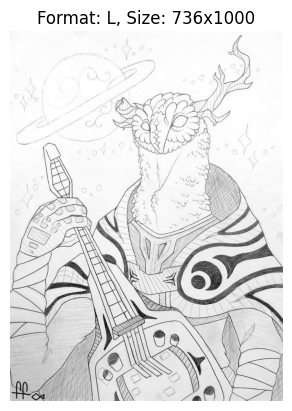

In [4]:
with Image.open(BASE_IMAGE_PATH + "original-pendrawn.jpg") as img:
    img = img.convert(mode="L")
    img.save(BASE_IMAGE_PATH + "grayscale.jpg")

process_image("grayscale.jpg", "L")

raw_size=2437737, 1/ratio=3.6924108076013096 (compressed)


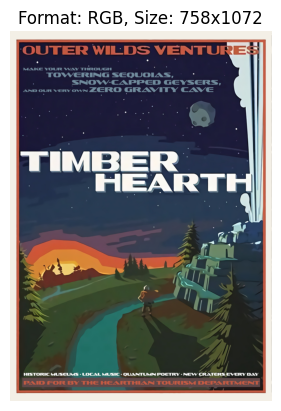

In [5]:
with Image.open(BASE_IMAGE_PATH + "original-poster.png") as img:
    img = img.resize((img.width // 2, img.height // 2))
    img.save(BASE_IMAGE_PATH + "color.png")

process_image("color.png", "RGB")

In [6]:
def prepare_russian_text():
    with open("resources/Вино-из-одуванчиков.txt", "r", encoding="windows-1251") as f:
        data = f.read()
    
    with open("resources/Вино-из-одуванчиков.txt", "w", encoding="utf-8") as f:
        f.write(data)

# prepare_russian_text()

In [7]:
resouces = {
    "img-rgb": "resources/images/color.png.raw",
    "img-l": "resources/images/grayscale.jpg.raw",
    "img-1": "resources/images/monochrome.png.raw",
    "bin": "resources/7z-arm64.exe",
    "enwik7": "resources/enwik7.txt",
    "rustext": "resources/Вино-из-одуванчиков.txt"
}